# Исследование запутанности между концами цепочки из БЭК кубитов

In [1]:
from fractions import Fraction

In [2]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import qutip
import joblib

In [4]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar

## Энропия между концами цепочкек различной длины

In [5]:
%%time

n_bosons = 20
i_projection = n_bosons

tspan = np.linspace(0, 1.5, 301)

entropy_vn_spans = [
    (
        m_sites_,
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.rho_b_ent)(
                t,
                p=i_projection,
                k=(n_bosons,) * (m_sites_ // 2 - ((m_sites_ + 1) % 2)),
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [3, 4, 5]
]

100%|██████████| 301/301 [01:30<00:00,  3.33it/s]


CPU times: user 584 ms, sys: 267 ms, total: 851 ms
Wall time: 3min 9s


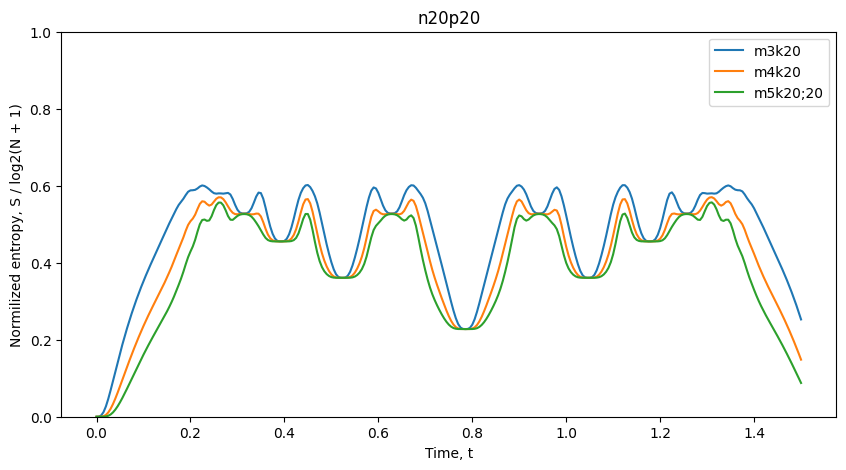

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m_sites_, entropy_vn_span in entropy_vn_spans:
    label = f"m{m_sites_}k{';'.join(map(str, (n_bosons,) * (m_sites_ // 2 - ((m_sites_ + 1) % 2))))}"
    ax.plot(tspan, entropy_vn_span / np.log2(n_bosons + 1), label=label)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Normilized entropy, S / log2(N + 1)")
ax.set_xlabel("Time, t")
ax.set_ylim(0, 1)
ax.legend()

plt.savefig("../../assets/entropy_vn_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

## Энропия между концами цепочкек с различным случаями измерения

### В результате измерения все нули

In [6]:
%%time

n_bosons = 20
i_projection = 0

tspan = np.linspace(0, 1.5, 301)

entropy_vn_spans = [
    (
        m_sites_,
        (k_mesuared_ := ((0,) * (m_sites_ // 2 - ((m_sites_ + 1) % 2)))),
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.rho_b_ent)(
                t,
                p=i_projection,
                k=k_mesuared_,
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [3, 4, 5]
]

100%|██████████| 301/301 [01:45<00:00,  2.85it/s]


CPU times: user 710 ms, sys: 277 ms, total: 987 ms
Wall time: 3min 45s


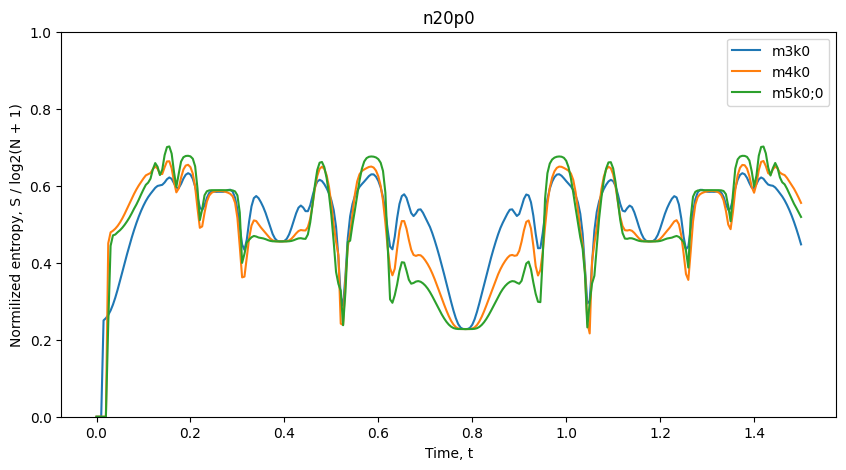

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m_sites_, k_mesuared_, entropy_vn_span in entropy_vn_spans:
    label = f"m{m_sites_}k{';'.join(map(str, k_mesuared_))}"
    ax.plot(tspan, entropy_vn_span / np.log2(n_bosons + 1), label=label)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Normilized entropy, S / log2(N + 1)")
ax.set_xlabel("Time, t")
ax.set_ylim(0, 1)
ax.legend()

plt.savefig("../../assets/entropy_vn_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

### В результате измерения случайная последовательность 

In [8]:
%%time

n_bosons = 20
i_projection = 0
k_mesuared = [13, 1, 19, 16, 6, 5, 6]

tspan = np.linspace(0, 1.5, 301)

entropy_vn_spans = [
    (
        m_sites_,
        (k_mesuared_ := k_mesuared[:(m_sites_ // 2 - ((m_sites_ + 1) % 2))]),
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.rho_b_ent)(
                t,
                p=i_projection,
                k=k_mesuared_,
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [3, 4, 5]
]

100%|██████████| 301/301 [01:47<00:00,  2.80it/s]


CPU times: user 955 ms, sys: 247 ms, total: 1.2 s
Wall time: 4min 9s


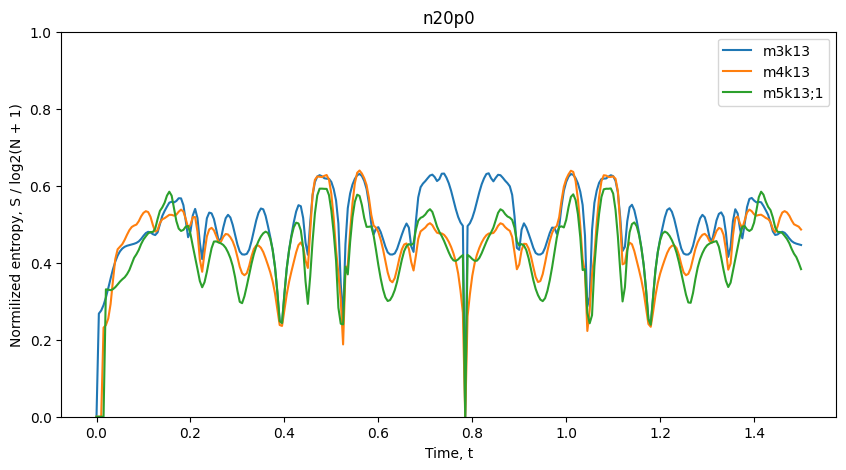

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m_sites_, k_mesuared_, entropy_vn_span in entropy_vn_spans:
    label = f"m{m_sites_}k{';'.join(map(str, k_mesuared_))}"
    ax.plot(tspan, entropy_vn_span / np.log2(n_bosons + 1), label=label)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Normilized entropy, S / log2(N + 1)")
ax.set_xlabel("Time, t")
ax.set_ylim(0, 1)
ax.legend()

plt.savefig("../../assets/entropy_vn_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

## Фиделити

In [22]:
%%time

n_bosons = 10
i_projection = 0
k_mesuared = [n_bosons] * 5

tspan = np.linspace(0, 1.5, 301)

fidelity_spans = [
    (
        m_sites_,
        (k_mesuared_ := k_mesuared[:(m_sites_ // 2 - ((m_sites_ + 1) % 2))]),
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.f_state_fidelity_even)(
                t,
                p=i_projection,
                k=k_mesuared_,
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [4, 6]
]

100%|██████████| 301/301 [00:00<00:00, 1253.59it/s]


CPU times: user 95.4 ms, sys: 67.4 ms, total: 163 ms
Wall time: 1.66 s


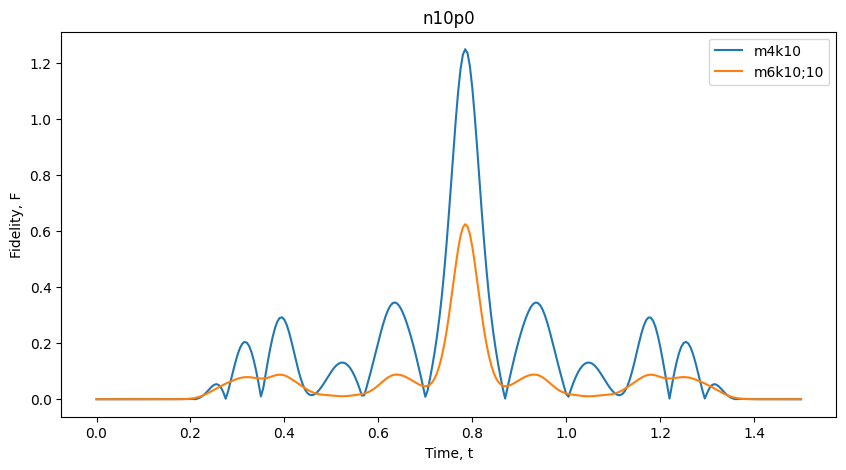

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m_sites_, k_mesuared_, fidelity_span in fidelity_spans:
    label = f"m{m_sites_}k{';'.join(map(str, k_mesuared_))}"
    ax.plot(tspan, fidelity_span, label=label)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, F")
ax.set_xlabel("Time, t")
# ax.set_ylim(0, 1)
ax.legend()

plt.savefig("../../assets/fidelity_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

### Нормировка

In [24]:
%%time

norm_spans = [
    (
        m_sites_,
        (k_mesuared_ := k_mesuared[:(m_sites_ // 2 - ((m_sites_ + 1) % 2))]),
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.f_state_norm_even)(
                t,
                p=i_projection,
                k=k_mesuared_,
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [4, 6]
]

100%|██████████| 301/301 [02:21<00:00,  2.13it/s]


CPU times: user 356 ms, sys: 131 ms, total: 487 ms
Wall time: 2min 26s


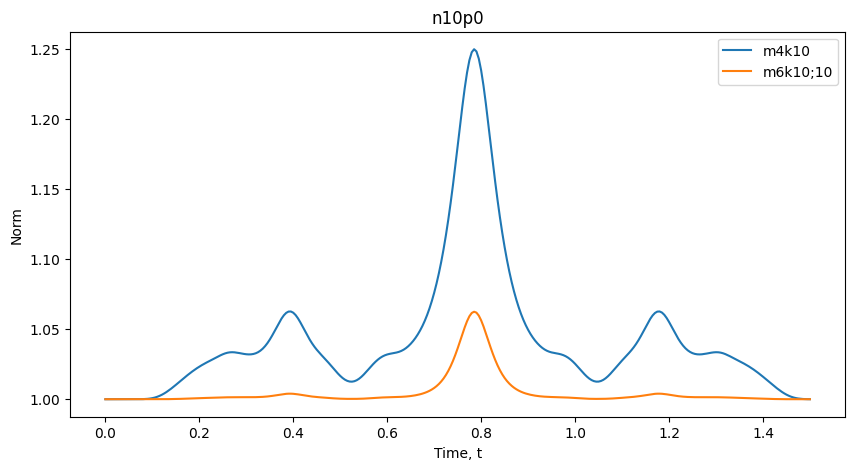

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m_sites_, k_mesuared_, norm_span in norm_spans:
    label = f"m{m_sites_}k{';'.join(map(str, k_mesuared_))}"
    ax.plot(tspan, norm_span, label=label)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Norm")
ax.set_xlabel("Time, t")
# ax.set_ylim(0, 1)
ax.legend()

plt.savefig("../../assets/norm_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

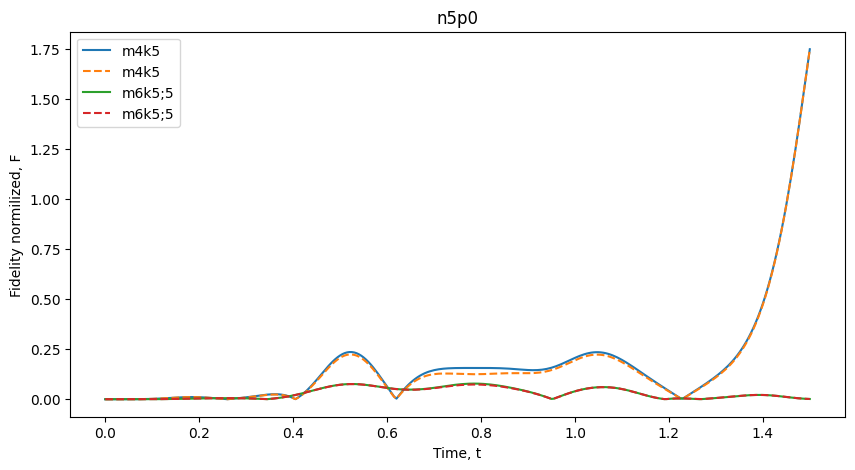

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for (m_sites_, k_mesuared_, fidelity_span), (_, _, norm_span) in zip(fidelity_spans, norm_spans):
    label = f"m{m_sites_}k{';'.join(map(str, k_mesuared_))}"
    ax.plot(tspan, fidelity_span, label=label)
    ax.plot(tspan, fidelity_span / np.array(norm_span), "--", label=label)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity normilized, F")
ax.set_xlabel("Time, t")
# ax.set_ylim(0, 1)
ax.legend()

# plt.savefig("../../assets/fidelity_normilized_span" + f"_p{i_projection}n{n_bosons}mX" + ".pdf")

## Численное решение

$<kx|\psi> = <k|H|\psi>$ 

$X|\psi> = |\psi^1>$ 

$|\psi^1><\psi^1|$

$|k> = K |0>$

$|k><k| |\psi(t)>$

$<k_2|\psi(t)> = <k_2||\psi(t)>_1 |\psi(t)>_2 |\psi(t)>_3$

$Tr_2\{|k_2><k_2|\psi(t)\}>$

$Tr_2\{K|0><0|K^*\psi(t)\}>$

$Tr_2\{KK^*\psi(t)\}> = Tr_2\{KK^*\Psi(t)|0>\}> $

$<0|\rho|0> + <1|\rho|1>$

In [33]:
%%time
n_bosons = 10
model = bec.BEC_Qubits.init_default(n_bosons, 0)
m = 3
i_projection = n_bosons
hzz = sum(bec.sz(model, n=m, k=i) * bec.sz(model, n=m, k=i+1) for i in range(m - 1))
init_state = math.prod((bec.coherent_state_constructor(model, n=m, k=i) for i in range(m))) * bec.vacuum_state(model, n=m)

CPU times: user 2.44 s, sys: 512 ms, total: 2.96 s
Wall time: 3.09 s


In [16]:
tspan = np.linspace(0, 1.5, 301)
states_hzz_n3 = qutip.sesolve(hzz, init_state, tspan, progress_bar=TqdmProgressBar()).states
states_hzz_n2_teor = [bec.state_under_h_zz_teor(model, t / model.Omega) for t in tqdm(tspan)]

100%|██████████| 301/301 [00:20<00:00, 15.03it/s]


In [17]:
mesuare_x = bec.fock_x_state_constructor(model, n=m, i=1, k=i_projection) #* bec.vacuum_state(model, n=n)
mesuare_x_op = mesuare_x * mesuare_x.dag()

In [18]:
states_hzz_n3_x = [mesuare_x_op * s for s in tqdm(states_hzz_n3)]

100%|██████████| 301/301 [00:06<00:00, 44.71it/s]


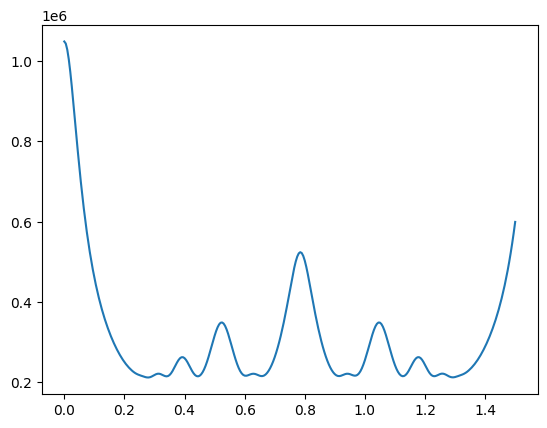

In [19]:
plt.plot(tspan, [(s.dag() * s).full()[0] for s in states_hzz_n3_x])

In [20]:
entropy_hzz_n2_teor = [qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2) for s in tqdm(states_hzz_n2_teor)]
entropy_hzz_n3 = [qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2) for s in tqdm(states_hzz_n3)]
entropy_hzz_n3_x = [entanglement_propagation.entropy_vn(qutip.ptrace(s, [0, 1]), base=2) for s in tqdm(states_hzz_n3_x)]
# concurrence_hzz_n3_x = [qutip.entropy.concurrence(s) for s in tqdm(states_hzz_n3_x)]
entropy_vn_spans = [
    (
        m_sites_,
        joblib.Parallel(n_jobs=-2)(
            joblib.delayed(entanglement_propagation.rho_b_ent)(
                t,
                p=i_projection,
                k=(n_bosons,) * (m_sites_ // 2 - ((m_sites_ + 1) % 2)),
                m=m_sites_,
                n=n_bosons,
            )
            for t in tqdm(tspan)
        ),
    )
    for m_sites_ in [3, 4, 5]
]

100%|██████████| 301/301 [00:05<00:00, 60.09it/s]


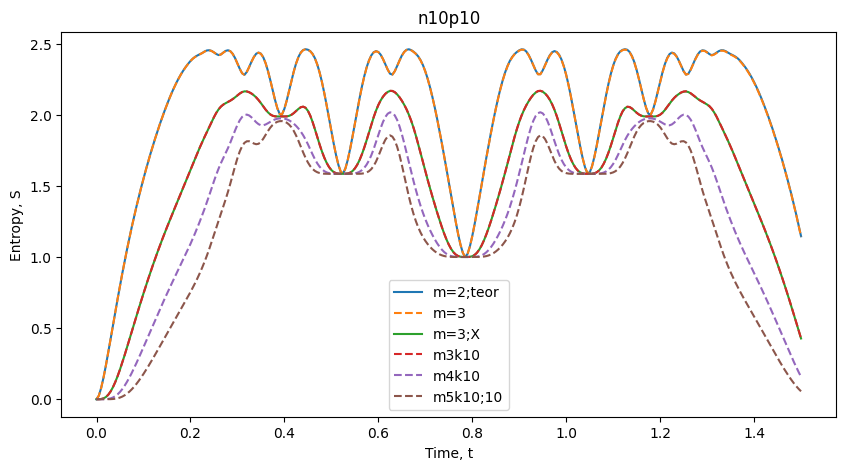

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(tspan, entropy_hzz_n2_teor, label=f"m=2;teor")
ax.plot(tspan, entropy_hzz_n3, "--", label=f"m={m}")
ax.plot(tspan, entropy_hzz_n3_x, "-", label=f"m={m};X")
for m_sites_, entropy_vn_span in entropy_vn_spans:
    label = f"m{m_sites_}k{';'.join(map(str, (n_bosons,) * (m_sites_ // 2 - ((m_sites_ + 1) % 2))))}"
    ax.plot(tspan, entropy_vn_span, "--", label=label)
ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Entropy, S")
ax.set_xlabel("Time, t")
ax.legend()

## Энропия c разым числом базонов

In [173]:
%%time

m = 2
tmax =  np.pi / 6 
n_ts = 301
tspan = np.linspace(0, tmax, n_ts)
evolutions = {}
for n_bosons in range(2, 35, 1):
    model = bec.BEC_Qubits.init_default(n_bosons, 0)
    hzz = sum(bec.sz(model, n=m, k=i) * bec.sz(model, n=m, k=i+1) for i in range(m - 1))
    init_state = math.prod((bec.coherent_state_constructor(model, n=m, k=i) for i in range(m))) * bec.vacuum_state(model, n=m)
    states_hzz_n2_teor = joblib.Parallel(n_jobs=-2)(
        joblib.delayed(bec.state_under_h_zz_teor)(model, t / model.Omega) 
        for t in tqdm(tspan, postfix=f"b{n_bosons}m{m};teor")
    )
    evolutions[(n_bosons, m, tmax, n_ts)] = states_hzz_n2_teor

 84%|████████▎ | 252/301 [50:08<09:40, 11.86s/it]/Users/kephircheek/venvs/science/emqwuqoc-dev/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 16%|█▋        | 49/301 [24:46<2:14:15, 31.97s/it]

KeyboardInterrupt: 

In [213]:
entropies = {}
for (n_bosons, m, tmax, n_ts), evolution in evolutions.items():
    tspan = np.linspace(0, tmax, n_ts) 
    entropy_hzz_n2_teor = joblib.Parallel(n_jobs=-2)(
        joblib.delayed(qutip.entropy.entropy_vn)(qutip.ptrace(s, [0, 1]), base=2) 
        for s in tqdm(evolution, postfix=f"b{n_bosons}m{m};teor", disable=True)
    )
    print(f"b{n_bosons}m{m};teor")
    entropies[(n_bosons, m, tmax, n_ts)] = entropy_hzz_n2_teor

b2m2;teor
b3m2;teor
b4m2;teor
b5m2;teor
b6m2;teor
b7m2;teor
b8m2;teor
b9m2;teor
b10m2;teor
b11m2;teor
b12m2;teor
b13m2;teor
b14m2;teor
b15m2;teor
b16m2;teor
b17m2;teor
b18m2;teor
b19m2;teor
b20m2;teor
b21m2;teor
b22m2;teor
b23m2;teor
b24m2;teor
b25m2;teor
b26m2;teor
b27m2;teor
b28m2;teor
b29m2;teor
b30m2;teor
b31m2;teor
b32m2;teor


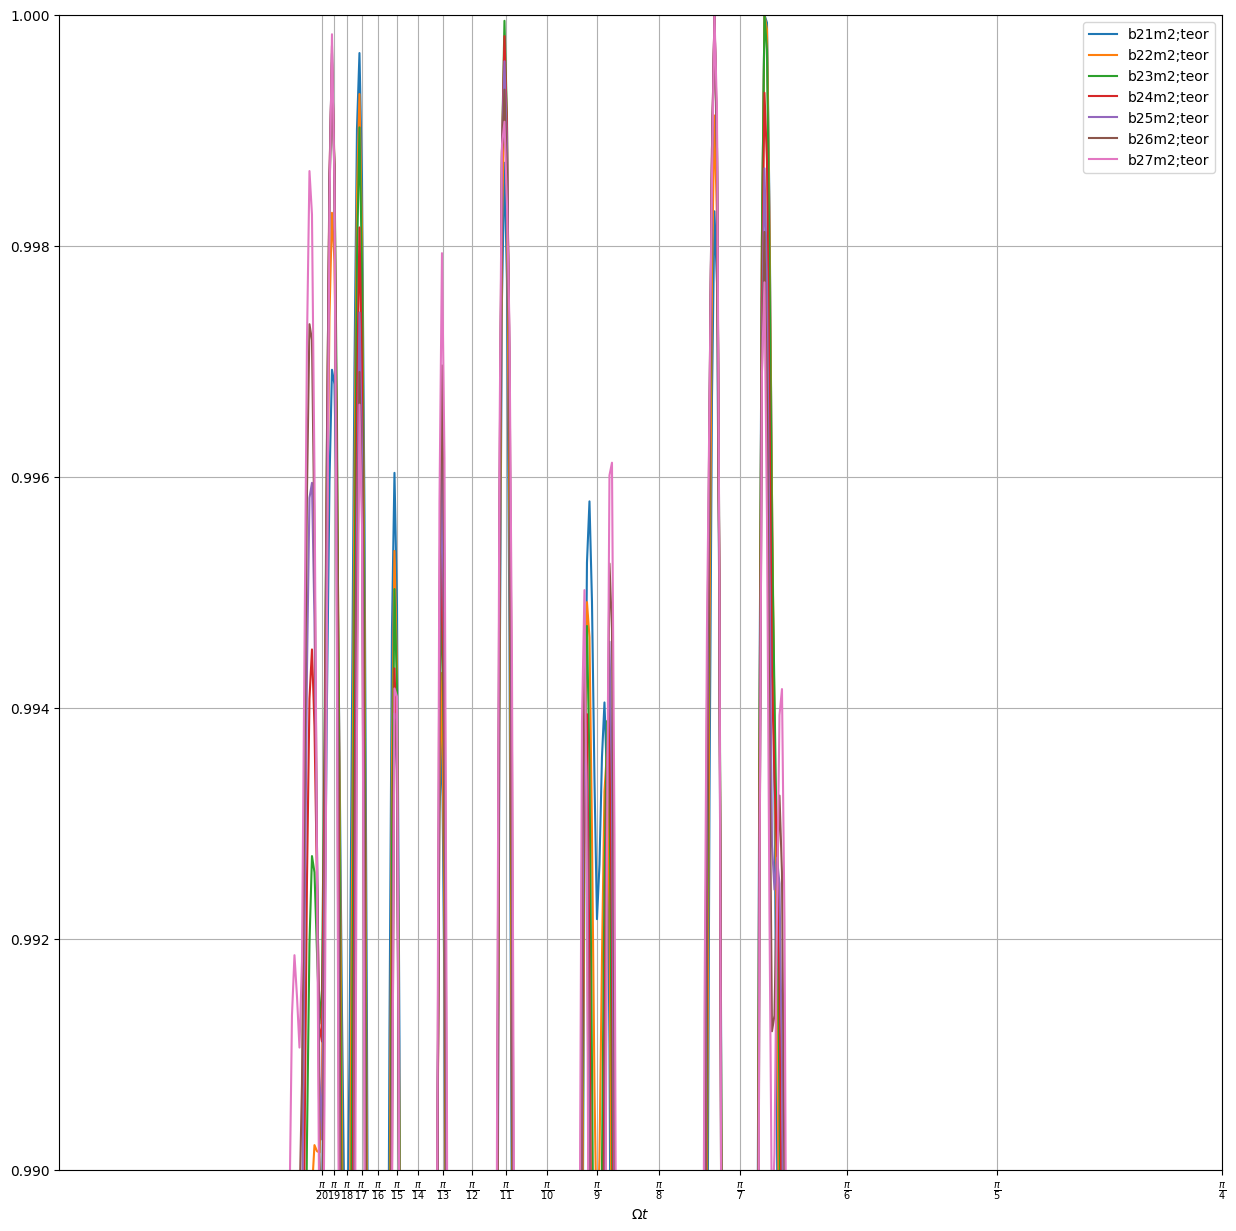

In [237]:
_, ax = plt.subplots(1, 1, figsize=(15, 15))

t_maxs = {}

for (n_bosons, m, tmax, n_ts), entropy_hzz_n2_teor in entropies.items():
    if n_bosons not in range(21, 28):
        continue
    tspan = np.linspace(0, tmax, n_ts) 
    # ax.plot(tspan, entropy_hzz_n2_teor / np.log2(n_bosons + 1), label=f"b{n_bosons}m{m};teor")
    # ax.plot(tspan, entropy_hzz_n2_teor, label=f"b{n_bosons}m{m};teor")
    i_of_max_e = np.argmax(entropy_hzz_n2_teor)
    max_e, t_of_max_e = entropy_hzz_n2_teor[i_of_max_e], tspan[i_of_max_e]
    t_maxs[(n_bosons, m, tmax, n_ts)] = t_of_max_e
    # ax.plot(t_of_max_e, max_e / np.log2(n_bosons + 1), "*k")
    ax.plot(tspan, np.array(entropy_hzz_n2_teor) / max_e, label=f"b{n_bosons}m{m};teor")
    
# ax.set_xticks([np.pi / i   for i in range(10)], ["%spi/%s" % Fraction(i, 72).as_integer_ratio() for i in range(19)])
ax.set_xticks([np.pi / i for i in range(4, 21)], [rf"$\frac{{\pi}}{{{i}}}$"  for i in range(4, 21)])
ax.set_xlabel(r"$\Omega t$")
ax.legend()
ax.set_ylim(0.99, 1)
ax.grid()

In [215]:
cases, t = zip(*sorted(list(t_maxs.items())))
bosons = [c[0] for c in cases]
t = np.array(t)

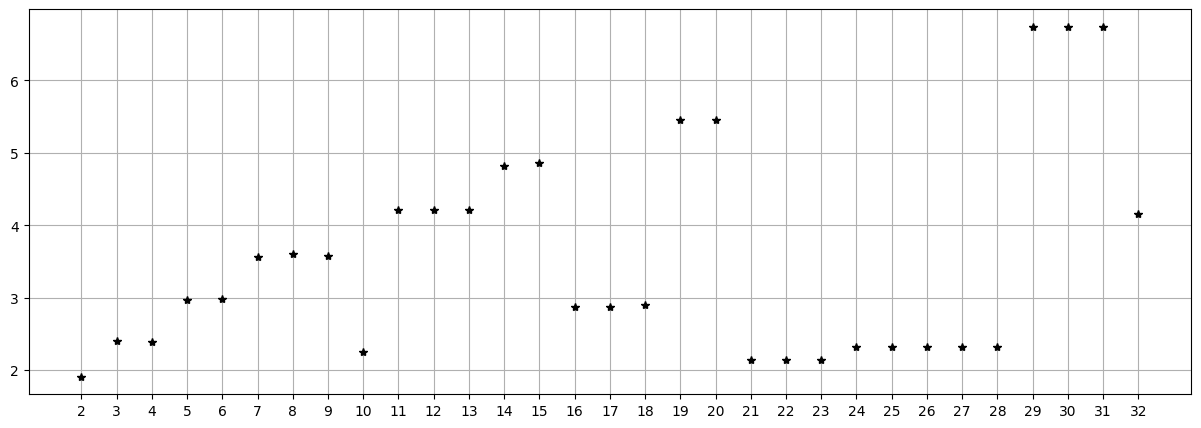

In [224]:
t_inv = 1 / t
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(bosons, t_inv, "*k")
ax.set_xticks(bosons)
ax.grid()

(0.41713369122664473, 0.41887902047863906)

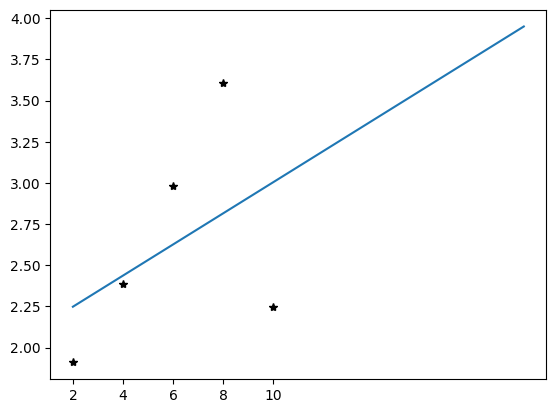

In [150]:
from scipy.stats import linregress

lr = linregress(bosons, t_inv)

plt.plot(bosons, t_inv, "*k")
plt.plot(range(2, 21), lr.slope * range(2, 21) + lr.intercept, "-")
plt.xticks(bosons);

In [133]:
lr

LinregressResult(slope=0.20176505302561157, intercept=1.7908337479525493, rvalue=0.9997727440900803, pvalue=4.11236667967901e-06, stderr=0.0024838876103462225, intercept_stderr=0.024714369674792746)

In [134]:
0.2 / t * 0.2 + 1.79 = N 

t = 0.2 / (N + 1.79)

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (3283861990.py, line 1)

In [155]:
7 * 8

56

In [ ]:
np.pi 

In [106]:
1 / 1.59

0.6289308176100629

In [101]:
(bosons[-1] - bosons[0]) / (t_inv[-1] - t_inv[0]) 

1.59

In [99]:
(t_inv[-1] - t_inv[0])

7.547169811320754

In [102]:
21000 / 3600

5.833333333333333

## ?

### Фиделити

In [26]:
fid_n3_x = [s1.dag() * qutip.ptrace(s2, [0, 1, 4, 5]) for s1, s2 in tqdm(zip(states_hzz_n2_teor, states_hzz_n3_x))]

2it [00:31, 15.67s/it]

KeyboardInterrupt: 

### Запутаность через f_state и rho_b


100%|██████████| 301/301 [00:00<00:00, 3519.94it/s]
2it [20:12:20, 36370.25s/it]
100%|██████████| 301/301 [00:05<00:00, 56.70it/s]


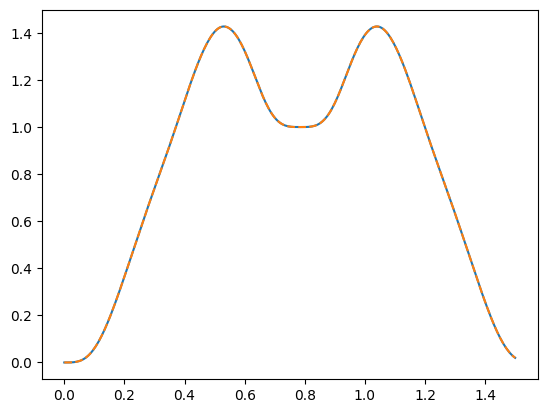

In [36]:
args = (3, (3,), 3, 3)

plt.plot(
    tspan, 
    [entanglement_propagation.rho_b_ent(t, *args) for t in tqdm(tspan)]
)

#plt.plot(
#    tspan, 
#    [qutip.entropy.entropy_vn(qutip.Qobj(entanglement_propagation.rho_b(t, *args[1:]))) for t in tqdm(tspan)]
#)

plt.plot(
    tspan, 
    [entanglement_propagation.entropy_vn(qutip.ptrace(entanglement_propagation.f_state(t, *args), [0, 1]), base=2) for t in tqdm(tspan)],
    "--"
)
